## Imports

# Clustering de documents

In [25]:
import collections
import os
import string
import sys
import pandas as pd
from nltk import word_tokenize
from nltk.corpus import stopwords
from pprint import pprint
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine

In [2]:
import nltk

nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aspng\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aspng\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
from pathlib import Path

data_path = Path("../../data/txt")
if not data_path.exists():
    data_path = Path("C:/Users/aspngp/Downloads/tac/data/txt")

files = [f.name for f in data_path.glob("*.txt")]

## Choisir une décennie

In [27]:
DECADE = '1950'

## Charger tous les  fichiers de la décennie et en créer une liste de textes

In [32]:

import re
files = [f for f in sorted(os.listdir(data_path)) if re.search(r"_195\d-", f)]

In [33]:
# Exemple de fichiers
files[:20]

['KB_JB838_1950-01-06_01-00002.txt',
 'KB_JB838_1950-01-07_01-00013.txt',
 'KB_JB838_1950-01-08_01-00011.txt',
 'KB_JB838_1950-01-10_01-00006.txt',
 'KB_JB838_1950-01-15_01-00010.txt',
 'KB_JB838_1950-01-22_01-00014.txt',
 'KB_JB838_1950-02-13_01-00005.txt',
 'KB_JB838_1950-02-13_01-00008.txt',
 'KB_JB838_1950-02-15_01-00011.txt',
 'KB_JB838_1950-02-15_01-00014.txt',
 'KB_JB838_1950-02-16_01-00014.txt',
 'KB_JB838_1950-02-17_01-00009.txt',
 'KB_JB838_1950-02-18_01-00009.txt',
 'KB_JB838_1950-02-18_01-00014.txt',
 'KB_JB838_1950-02-25_01-00006.txt',
 'KB_JB838_1950-02-25_01-00013.txt',
 'KB_JB838_1950-02-28_01-00012.txt',
 'KB_JB838_1950-03-01_01-00005.txt',
 'KB_JB838_1950-03-03_01-00013.txt',
 'KB_JB838_1950-03-05_01-00020.txt']

In [34]:
# Exemple de fichiers
files[:200]

['KB_JB838_1950-01-06_01-00002.txt',
 'KB_JB838_1950-01-07_01-00013.txt',
 'KB_JB838_1950-01-08_01-00011.txt',
 'KB_JB838_1950-01-10_01-00006.txt',
 'KB_JB838_1950-01-15_01-00010.txt',
 'KB_JB838_1950-01-22_01-00014.txt',
 'KB_JB838_1950-02-13_01-00005.txt',
 'KB_JB838_1950-02-13_01-00008.txt',
 'KB_JB838_1950-02-15_01-00011.txt',
 'KB_JB838_1950-02-15_01-00014.txt',
 'KB_JB838_1950-02-16_01-00014.txt',
 'KB_JB838_1950-02-17_01-00009.txt',
 'KB_JB838_1950-02-18_01-00009.txt',
 'KB_JB838_1950-02-18_01-00014.txt',
 'KB_JB838_1950-02-25_01-00006.txt',
 'KB_JB838_1950-02-25_01-00013.txt',
 'KB_JB838_1950-02-28_01-00012.txt',
 'KB_JB838_1950-03-01_01-00005.txt',
 'KB_JB838_1950-03-03_01-00013.txt',
 'KB_JB838_1950-03-05_01-00020.txt',
 'KB_JB838_1950-03-11_01-00005.txt',
 'KB_JB838_1950-03-15_01-00012.txt',
 'KB_JB838_1950-03-19_01-00001.txt',
 'KB_JB838_1950-03-25_01-00009.txt',
 'KB_JB838_1950-03-27_01-00002.txt',
 'KB_JB838_1950-03-29_01-00002.txt',
 'KB_JB838_1950-03-29_01-00008.txt',
 

In [35]:
texts = [open(data_path / f, "r", encoding="utf-8").read() for f in files]

In [36]:
# Exemple de textes
texts[5][:1400]


'14 . LE som DIMANCHE 22 JANVIER 1950 POUR SES FAMEUSES MACHINES UNIVERSELLES A POINTS DROIT ET ZIG-ZAG BERNINA EMPLOIE UNIQUEMENT DES ENGRENAGES GARANTISSANT UN FONCTIONNEMENT#D’UNE PRECISION ABSOLUE ET UNE LONGEVITE QUASI ILLIMITEE. SOUCIEUX DE SA REPUTATION BERNINA SE REFUSE D’AVOIR RECOURS A D’AUTRES DISPOSITIFS DE TRANSMISSION» BEAUCOUP MOINS ONEREUX, MAIS *QUI NE LUI DONNERAIENT PAS TOUTES GARANTIES. i Portable électrique, à points droit et zig-zag, avec moteur, eh valise, CL. 125. Broder, coudre des boutons, des agrafes, des œillets, faire des boutonnières devient un jeu d’enfant avec les BERNINA A POINTS DROIT ET ZIG - Z AG Fr. GEGÀUF, Soc. An., Steckborn (Suisse) Fabrique de Machines à coudre. Fondée en 1894. Modèle normal à points droit et zigzag sur bâti simple, meuble de luxe ou spècial pour force motrice CL. 117. PLUS DE 150 DISTRIBUTEURS AU SERVICE DE BERNINA. ATTENTION : DEMONSTRATION DES MACHINES BERNINA TOUS LES LUNDI, MERCREDI ET VENDREDI APRES-MIDI, AU CERCLE « FEMME

## Vectoriser les documents à l'aide de TF-IDF

In [37]:
# Création d'une fonction de pré-traitement
def preprocessing(text, stem=True):
    """ Tokenize text and remove punctuation """
    text = text.translate(string.punctuation)
    tokens = word_tokenize(text)
    return tokens

### Instancier le modèle TF-IDF avec ses arguments

In [38]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocessing,
    stop_words=stopwords.words('french'),
    max_df=0.5,
    min_df=0.1,
    lowercase=True)

### Construire la matrice de vecteurs à l'aide de la fonction `fit_transform`

In [39]:
tfidf_vectors = vectorizer.fit_transform(texts)

c:\Users\aspng\Downloads\tac\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [40]:
# Détail de la matrice
tfidf_vectors

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 703893 stored elements and shape (1000, 3507)>

### Imprimer le vecteur tf-IDF du premier document

In [41]:
pd.Series(
    tfidf_vectors[0].toarray()[0],
    index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=False)

parti             0.276943
loyer             0.152179
janvier           0.148008
populaire         0.147155
propriétaire      0.143668
                    ...   
étage             0.000000
établissements    0.000000
1/4               0.000000
1/2               0.000000
ét.               0.000000
Length: 3507, dtype: float64

## Comprendre les vecteurs et leurs "distances"

In [42]:
cosine([1, 2, 3], [1, 2, 3])

np.float64(0.0)

In [43]:
cosine([1, 2, 3], [1, 2, 2])

np.float64(0.02004211298777725)

In [44]:
cosine([1, 2, 3], [2, 2, 2])

np.float64(0.07417990022744858)

### Tests sur nos documents

In [45]:
tfidf_array = tfidf_vectors.toarray()

In [46]:
# Vecteur du document 0
tfidf_array[0]

array([0.       , 0.       , 0.       , ..., 0.       , 0.       ,
       0.0377286], shape=(3507,))

In [47]:
# Vecteur du document 1
tfidf_array[1]

array([0.        , 0.00670907, 0.        , ..., 0.        , 0.        ,
       0.        ], shape=(3507,))

In [48]:
cosine(tfidf_array[0], tfidf_array[1])

np.float64(0.9314334751415738)

## Appliquer un algorithme de clustering sur les vecteurs TF-IDF des documents

Pour en savoir plus sur le KMeans clustering :
- https://medium.com/dataseries/k-means-clustering-explained-visually-in-5-minutes-b900cc69d175

### Définir un nombre de clusters

In [49]:
N_CLUSTERS = 5

### Instancier le modèle K-Means et ses arguments

In [50]:
km_model = KMeans(n_clusters=N_CLUSTERS)

### Appliquer le clustering à l'aide de la fonction `fit_predict`

In [51]:
clusters = km_model.fit_predict(tfidf_vectors)

In [52]:
clustering = collections.defaultdict(list)

for idx, label in enumerate(clusters):
    clustering[label].append(files[idx])

In [53]:
pprint(dict(clustering))

{np.int32(0): ['KB_JB838_1950-01-07_01-00013.txt',
               'KB_JB838_1950-02-18_01-00014.txt',
               'KB_JB838_1950-02-28_01-00012.txt',
               'KB_JB838_1950-03-03_01-00013.txt',
               'KB_JB838_1950-03-15_01-00012.txt',
               'KB_JB838_1950-04-25_01-00011.txt',
               'KB_JB838_1950-05-24_01-00014.txt',
               'KB_JB838_1950-06-14_01-00014.txt',
               'KB_JB838_1950-07-02_01-00018.txt',
               'KB_JB838_1950-11-24_01-00015.txt',
               'KB_JB838_1950-11-28_01-00012.txt',
               'KB_JB838_1950-11-29_01-00013.txt',
               'KB_JB838_1950-12-20_01-00013.txt',
               'KB_JB838_1950-12-24_01-00017.txt',
               'KB_JB838_1951-01-21_01-00018.txt',
               'KB_JB838_1951-03-06_01-00014.txt',
               'KB_JB838_1951-08-19_01-00015.txt',
               'KB_JB838_1951-08-24_01-00013.txt',
               'KB_JB838_1951-09-04_01-00012.txt',
               'KB_JB838_1951-0

## Visualiser les clusters

### Réduire les vecteurs à 2 dimensions à l'aide de l'algorithme PCA
Cette étape est nécessaire afin de visualiser les documents dans un espace 2D

https://fr.wikipedia.org/wiki/Analyse_en_composantes_principales

In [54]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(tfidf_vectors.toarray())

In [55]:
reduced_vectors[:10]

array([[-0.32580477,  0.11475687],
       [ 0.113107  , -0.30249501],
       [ 0.443548  , -0.25233582],
       [-0.23889493, -0.0386179 ],
       [-0.05146111, -0.10714144],
       [ 0.6130718 ,  0.50377462],
       [-0.20312618, -0.03802654],
       [-0.19455259, -0.03862071],
       [ 0.62401296,  0.45566189],
       [ 0.15627381, -0.01431676]])

### Générer le plot

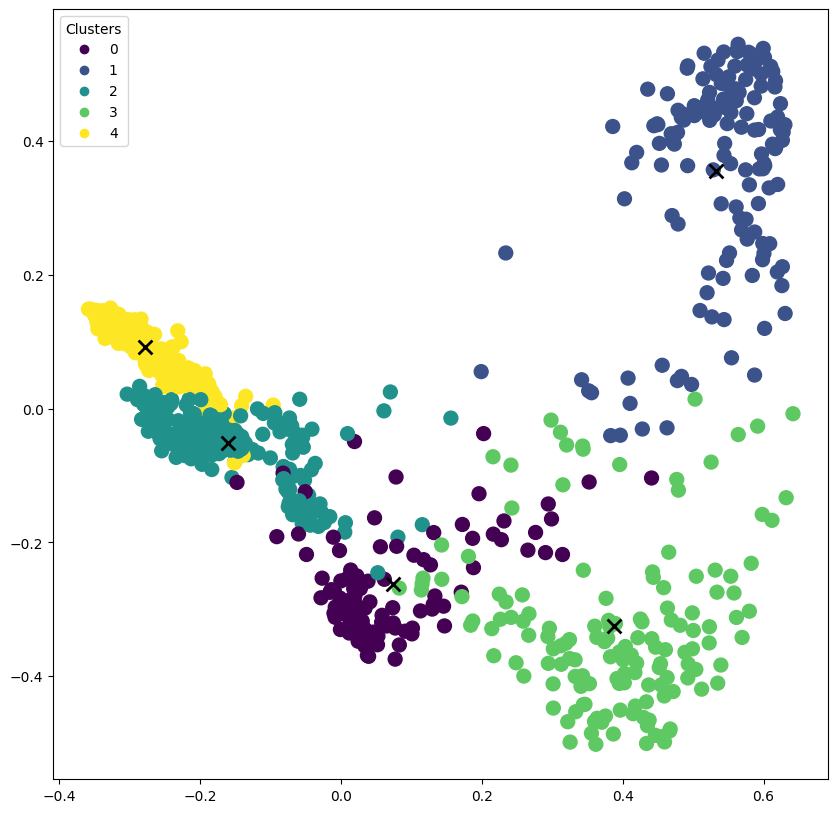

In [56]:
x_axis = reduced_vectors[:, 0]
y_axis = reduced_vectors[:, 1]

plt.figure(figsize=(10,10))
scatter = plt.scatter(x_axis, y_axis, s=100, c=clusters)

# Ajouter les centroïdes
centroids = pca.transform(km_model.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],  marker = "x", s=100, linewidths = 2, color='black')

# Ajouter la légende
plt.legend(handles=scatter.legend_elements()[0], labels=set(clusters), title="Clusters")

In [57]:
from collections import defaultdict
import os
import yake, pandas as pd
from pathlib import Path

In [58]:
# Instantier l'extracteur de mots clés
kw_extractor = yake.KeywordExtractor(lan="fr", top=200)
kw_extractor

In [22]:
from pathlib import Path
import shutil

# 1. Définition du chemin des données
data_path = Path("../../data/txt")
if not data_path.exists():
    data_path = Path("C:/Users/aspngp/Downloads/tac/data/txt")

output_dir = Path("./corpus_1950_1959")
output_dir.mkdir(parents=True, exist_ok=True)

# 2. Génération de la liste des années ['1970', '1971', ..., '1979']
years_1950s = [str(y) for y in range(1950, 1959)]

# 3. Filtrage : vérifie si au moins une année de la décennie apparaît dans le nom
files = [
    f for f in sorted(data_path.glob("*.txt"))
    if any(year in f.name for year in years_1950s)
]

# 4. Diagnostic de comptage par année
print(f"Total des fichiers détectés : {len(files)}\n")
print("--- Décomposition par année ---")
for year in years_1950s:
    count = sum(1 for f in files if year in f.name)
    print(f"Année {year} : {count} fichier(s)")

# 5. Copie des fichiers filtrés
for file_path in files:
    shutil.copy(file_path, output_dir / file_path.name)

print(f"\n {len(files)} fichiers copiés dans {output_dir}")

Total des fichiers détectés : 900

--- Décomposition par année ---
Année 1950 : 100 fichier(s)
Année 1951 : 100 fichier(s)
Année 1952 : 100 fichier(s)
Année 1953 : 100 fichier(s)
Année 1954 : 100 fichier(s)
Année 1955 : 100 fichier(s)
Année 1956 : 100 fichier(s)
Année 1957 : 100 fichier(s)
Année 1958 : 100 fichier(s)

 900 fichiers copiés dans corpus_1950_1959


In [68]:

from collections import defaultdict, Counter
import os, nltk, yake
from pathlib import Path
from nltk.corpus import stopwords

data_path = Path("./corpus_1950_1959")
if not data_path.exists():
    data_path = Path("C:/Users/aspngp/Downloads/tac/tps/tp3/corpus_1950_1959")
    
# stopwords : français + bruit du journal, petites annonces, etc
STOP = set(stopwords.words("french"))
STOP |= {"rossel","agence","ag","écr","écrire","adr","tél","téléph","fr","frs",
         "francs","août","juillet","juin","février","lundi","mardi","mercredi",
         "jeudi","vendredi","samedi","dimanche","hier","demain","matin","soir",
         "heures","jours","rue","av","maison","villa","appart","appartement",
         "louer","vendre","vend","jardin","garage","terrain","pièces","chambre",
         "cuisine","confort","belle","beau","bonne","bon","prix","occasion",
         "piano","radio","mariage","monsieur","madame","inut","interm",
         "s'abstenir","van","het","ville","jusqu","dit","fait","faire","être"}

def clean_text(text):
    tokens = nltk.wordpunct_tokenize(text.replace('\xa0', ' '))
    return [t for t in tokens if t.isalpha() and len(t) > 2 and t.lower() not in STOP]

# pour ouvrir + nettoyer + extraire (pas de filtre car le dossier concerne les docs de 1950-1959)
all_words, global_kw = [], defaultdict(list)
kw = yake.KeywordExtractor(lan="fr", n=2, top=100)

files = sorted(f for f in os.listdir(data_path) if f.endswith(".txt"))
for i, f in enumerate(files):
    raw = (data_path / f).read_text(encoding="utf-8")[:20000]  # articles, pas des annonces
    words = clean_text(raw)
    all_words += words
    for k, s in kw.extract_keywords(" ".join(words)):
        if len(k.split()) == 2:
            global_kw[k].append(s)
    if i % 100 == 0:
        print(f"{i}/{len(files)} fichiers...")

# Fichier propre pour le nuage de mots
out = data_path / "clean_1950_1959.txt"
out.write_text(" ".join(w.upper() for w in all_words), encoding="utf-8")
print("Fichier écrit :", out)

# Top 30 bigrammes de la décennie
print("\n--- Top 30 bigrammes 1950-1959 ---")
for k, scores in sorted(global_kw.items(), key=lambda kv: sum(kv[1])/len(kv[1]))[:30]:
    print(f"{k}\t{sum(scores)/len(scores):.3f}")


0/900 fichiers...
100/900 fichiers...
200/900 fichiers...
300/900 fichiers...
400/900 fichiers...
500/900 fichiers...
600/900 fichiers...
700/900 fichiers...
800/900 fichiers...
Fichier écrit : corpus_1950_1959\clean_1950_1959.txt

--- Top 30 bigrammes 1950-1959 ---
balle Topy	0.000
Topy balle	0.000
Topy CONCOURS	0.000
coup Idem	0.000
Idem coup	0.000
licence Sciences	0.000
Vander Borght	0.000
candidature Sciences	0.000
football Top	0.000
Idem Idem	0.000
Georges Vander	0.000
Entrée gratuite	0.000
raquette Donnay	0.000
VALEUR RÉELLE	0.000
Jokarl junior	0.000
Catégorie classe	0.000
Tailles Valeur	0.000
Janina Tolska	0.000
Estimation Catégorie	0.000
ANVERS Anvers	0.000
Donnay football	0.000
ser sem	0.000
Hillary Tensing	0.000
Top Jokarl	0.000
mètre Valeur	0.000
Rahmy Bey	0.000
LOT logements	0.000
Vendu Not	0.000
Jeunes vitesse	0.000
enfant balle	0.000


In [84]:
import nltk
import matplotlib.pyplot as plt
from pathlib import Path
from wordcloud import WordCloud
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

data_path = Path("./corpus_1950_1959")
if not data_path.exists():
    data_path = Path("C:/Users/aspngp/Downloads/tac/tps/tp3/corpus_1950_1959")

# Stopwords de base en français
sw = set(stopwords.words('french'))

In [100]:
# Stopwords (Idem que dans s1) 
#Stopwords en MAJUSCULES : NLTK passé en majuscules +  liste personnalisée car le clean_text est en majuscules
STOP_MAJ = {w.upper() for w in stopwords.words("french")}
STOP_MAJ ={"LES", "PLUS", "CETTE", "FAIT", "FAIRE", "ÊTRE", "DEUX", "COMME", "DONT", "TOUT",
 "ILS", "BIEN", "SANS", "PEUT", "TOUS", "APRÈS", "AINSI", "DONC", "CET", "SOUS",
 "CELLE", "ENTRE", "ENCORE", "TOUTES", "PENDANT", "MOINS", "DIRE", "CELA", "NON",
 "FAUT", "TROIS", "AUSSI", "DIT", "AVOIR", "DOIT", "CONTRE", "DEPUIS", "AUTRES",
 "VAN", "HET", "AUTRE", "JUSQU", "VILLE", "ROSSEL", "DEM", "PLUS", "TOUT", "CETTE",
 "SANS", "ANS", "TRÈS", "BIEN", "DEUX", "APRÈS", "TOUS", "COMME", "GRAND", "GRANDE",
 "GRANDS", "FAIT", "FAIRE", "ÊTRE", "PEUT", "MOINS", "ENCORE", "TOUJOURS", "DEM",
 "ECR", "ÉCRIRE", "APP", "DEMANDE", "ADR", "TÉL", "DEM", "ECR", "ÉCRIRE", "APP",
 "DEMANDE", "ADR", "TÉL", "BRUX", "BRUXELLES", "PLACE"}


In [101]:
# Vérifier le résultat
after = (data_path / "clean_1950_1959.txt").read_text(encoding="utf-8")
words = [w for w in after.split() if len(w) > 2 and w not in STOP_MAJ]
frequencies = Counter(words)

print(after[:1500])

IMPORTANTE MANIFESTATION FRANCO BELGE COMITÉ FRANCO BELGE COMMERCE INDUSTRIE AGRICULTURE COURS ANNÉE ÉCOULÉE CIRCONSTANCES PLUS DIFFICILES RENDU RELATIONS ÉCONOMIQUES ENTRE DEUX PAYS SERVICES CONSIDÉRABLES DONNERA JANVIER DÎNER ANNIVERSAIRE INSTALLATION COMITÉ FONCTIONNE BRUXELLES SOUS PRÉSIDENCE ANDRÉ VLIMANT PERMIS RÉALISER IMPORTANTS ÉCHANGES COMPENSÉS NOTAMMENT DOMAINE INDUSTRIE AGRICULTURE TRANSACTIONS DÉPASSANT HEURE ACTUELLE MONTANT MILLIONS BELGES DÎNER JANVIER EHAUSSÉ PRÉSENCE GASTON EYSKENS PREMIER MINISTRE HAUTS REPRÉSENTANTS AMBASSADE FRANCE LACOSTE MINISTRE FRANÇAIS INDUSTRIE COMMERCE FAURÉ SECRÉTAIRE ETAT BUDGET BURON SECRÉTAIRE ETAT AFFAIRES ECONOMIQUES JULIEN DÉPUTÉ RHÔNE ANCIEN MINISTRE PRÉSIDENT COMITÉ RÉPUBLICAIN MINISTRES BELGES LIEBAERT DUVIEUSART REY AINSI HAUTES PERSONNALITÉS FRANÇAISES BELGES ADMINISTRATION INDUSTRIE COURS DÎNER EYSKENS FERA EXPOSÉ ÉTAT RELATIONS ÉCONOMIQUES FINANCIÈRES ENTRE FRANCE BELGIQUE MOMENT AMORCENT NÉGOCIATIONS VUE ENTENTE FRANCE BENELU

In [105]:

for w, c in frequencies.most_common(30):
    print(f"  {w}\t{c}")

  ECRIRE	2575
  MOIS	2050
  LIBRE	2044
  PART	1997
  MOD	1825
  ÉTAT	1809
  VIS	1751
  CONF	1713
  PAYS	1647
  BELGIQUE	1628
  PRÉS	1559
  COURS	1557
  ANVERS	1546
  AVENUE	1507
  VENTE	1498
  PEU	1490
  GAR	1489
  ETC	1484
  TEMPS	1481
  TOUTE	1480
  BEL	1473
  BELGE	1435
  JOUR	1434
  LEURS	1409
  NEUF	1402
  AVANT	1384
  MIDI	1320
  SERVICE	1318
  PRÉSIDENT	1304
  PARIS	1282


In [108]:
fdist = nltk.FreqDist(kept)
fdist.most_common(20)

[(('som VENDREDI', np.float64(0.01855919335507438)), 1),
 (('Chartreux Brux.', np.float64(0.02182788168857041)), 1),
 (('LEVER Avez-vous', np.float64(0.024906581231243827)), 1),
 (('BRUXELLES Tél', np.float64(0.027276820277857525)), 1),
 (('frs Tél', np.float64(0.05234453939538279)), 1),
 (('CHARTREUX BRUXELLES', np.float64(0.06370315260334417)), 1),
 (('RUE ROYALE', np.float64(0.07817500159000297)), 1),
 (('rue Ballu', np.float64(0.08049385386994715)), 1),
 (('BEAU CAFE', np.float64(0.08082342748256702)), 1),
 (('rue Gray', np.float64(0.08455267795016379)), 1),
 (('BRUXELLES Hypothèques', np.float64(0.10966909215090309)), 1),
 (('CONGO BELGE', np.float64(0.11131933416329812)), 1),
 (('Neufchàtel Tél', np.float64(0.11318271692979247)), 1),
 (('Grand choix', np.float64(0.11602298657165652)), 1),
 (('BEAU SECRETAIRE', np.float64(0.11892494098077482)), 1),
 (('TAUX REDUITS', np.float64(0.11963107166185544)), 1),
 (('FONDS Tél', np.float64(0.1218650612696365)), 1),
 (('Bruxell Tél', np.flo

In [110]:
#Détecter les Hapax (mots qui n'apparaissent qu'une fois dans le corpus_1950_1959)

fdist.hapaxes()[:30]

[('som VENDREDI', np.float64(0.01855919335507438)),
 ('Chartreux Brux.', np.float64(0.02182788168857041)),
 ('LEVER Avez-vous', np.float64(0.024906581231243827)),
 ('BRUXELLES Tél', np.float64(0.027276820277857525)),
 ('frs Tél', np.float64(0.05234453939538279)),
 ('CHARTREUX BRUXELLES', np.float64(0.06370315260334417)),
 ('RUE ROYALE', np.float64(0.07817500159000297)),
 ('rue Ballu', np.float64(0.08049385386994715)),
 ('BEAU CAFE', np.float64(0.08082342748256702)),
 ('rue Gray', np.float64(0.08455267795016379)),
 ('BRUXELLES Hypothèques', np.float64(0.10966909215090309)),
 ('CONGO BELGE', np.float64(0.11131933416329812)),
 ('Neufchàtel Tél', np.float64(0.11318271692979247)),
 ('Grand choix', np.float64(0.11602298657165652)),
 ('BEAU SECRETAIRE', np.float64(0.11892494098077482)),
 ('TAUX REDUITS', np.float64(0.11963107166185544)),
 ('FONDS Tél', np.float64(0.1218650612696365)),
 ('Bruxell Tél', np.float64(0.12777611411104645))]

In [112]:
from collections import Counter
from wordcloud import WordCloud
import os
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from IPython.display import Image

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aspng\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


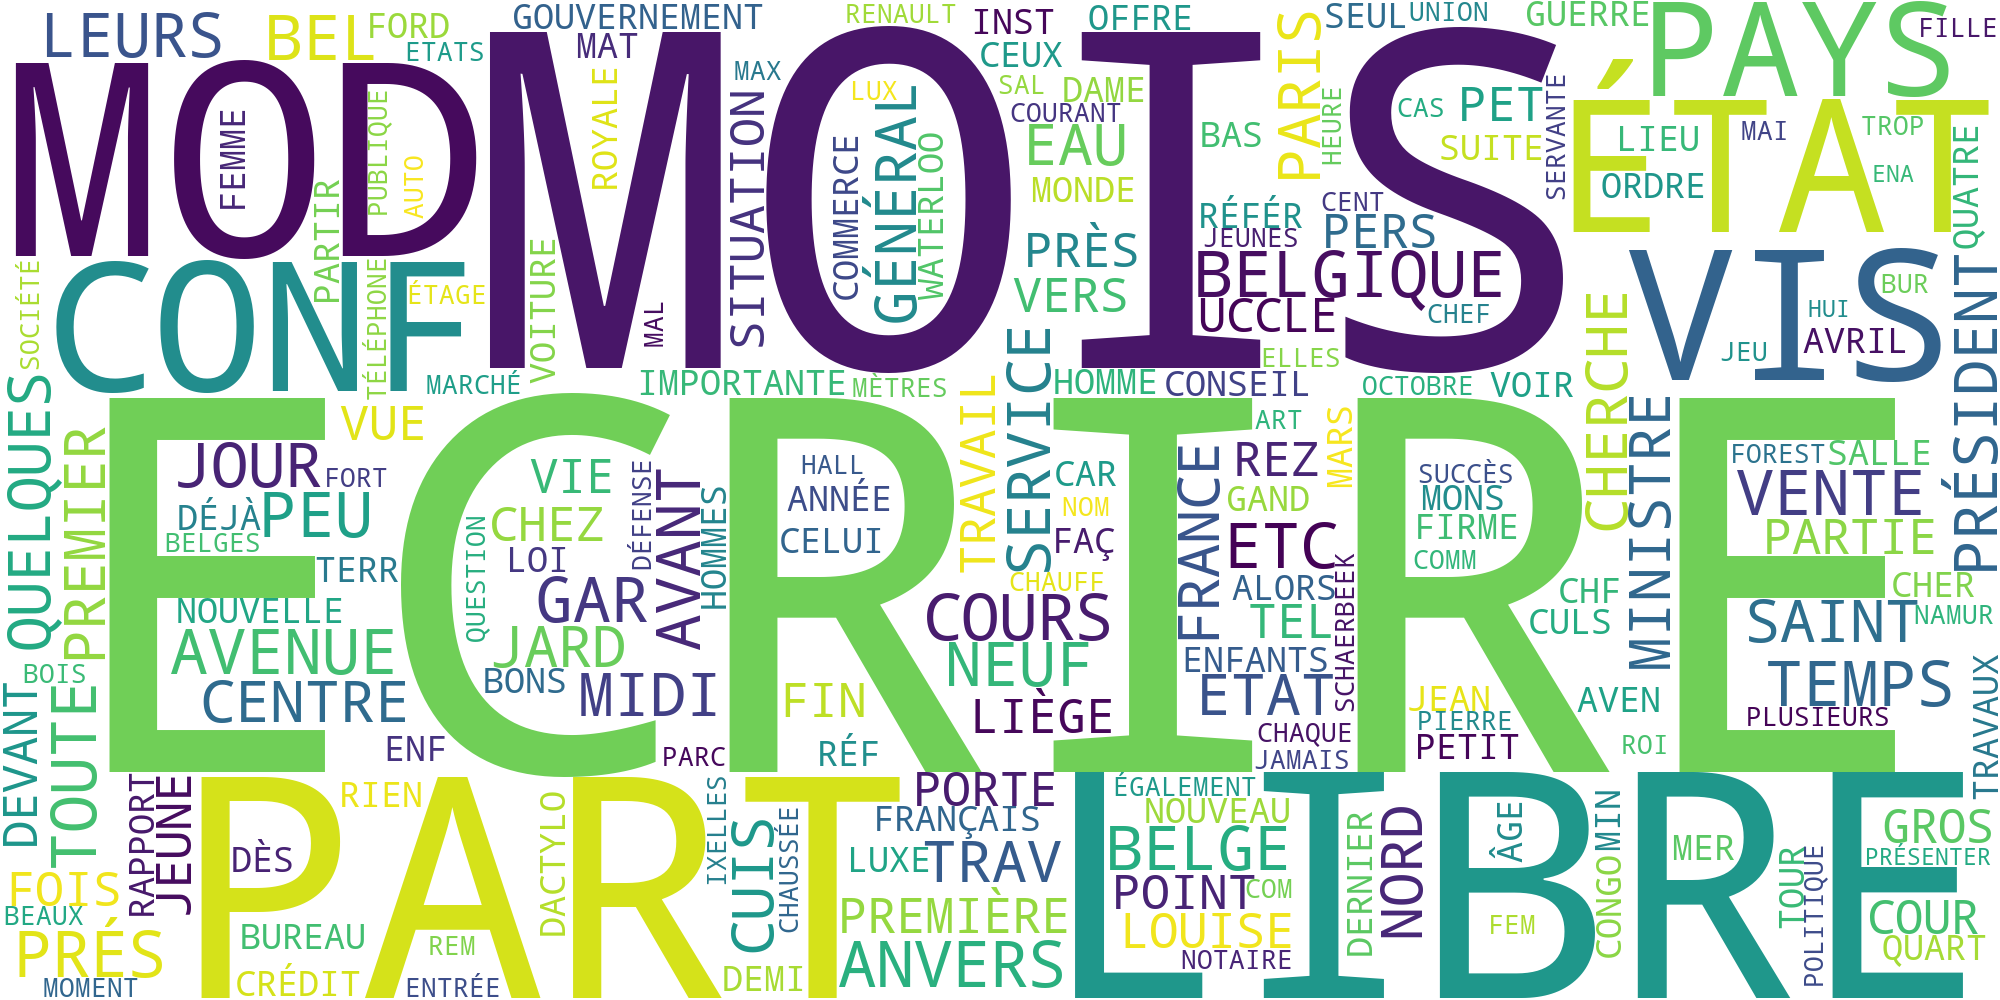

In [113]:
data_path = Path("./corpus_1950_1959")
if not data_path.exists():
    data_path = Path("C:/Users/aspngp/Downloads/tac/tps/tp3/corpus_1950_1959")
    
#Fréquences sur les tokens filtres
after = (data_path / "clean_1950_1959.txt").read_text(encoding="utf-8")
words = [w for w in after.split() if len(w) > 2 and w not in STOP_MAJ]
frequencies = Counter(words)

png_path = data_path / "nuage_1950_1959.png"
cloud = WordCloud(width=2000, height=1000, background_color='white', max_words=200)
cloud.generate_from_frequencies(frequencies)
cloud.to_file(str(png_path))

# Affichage
Image(filename=str(png_path))

In [139]:
import sys

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

import nltk
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode

In [119]:
class MySentences(object):
    """Tokenize and Lemmatize sentences"""
    def __init__(self, filename):
        self.filename = filename

    def __iter__(self):
        for line in open(self.filename, encoding='utf-8', errors="backslashreplace"):
            yield [unidecode(w.lower()) for w in wordpunct_tokenize(line)]

In [122]:
infile = f"C:/Users/aspng/Downloads/tac/data/sents1.txt"
sentences = MySentences(infile)

In [123]:
bigram_phrases = Phrases(sentences)

In [124]:
len(bigram_phrases.vocab.keys())

4310398

In [125]:
key_ = list(bigram_phrases.vocab.keys())[144]
print(key_)

1q


In [126]:
bigram_phrases.vocab[key_]

42

In [130]:
trigram_phrases = Phrases(bigram_phraser[sentences])

In [127]:
bigram_phraser = Phraser(phrases_model=bigram_phrases)

In [131]:
trigram_phraser = Phraser(phrases_model=trigram_phrases)

In [133]:
corpus = list(trigram_phraser[bigram_phraser[sentences]])

In [135]:
print(corpus[:300])

[['mi', 'imnri', 'r', 'i', '<<', 'i', 'i', 'hmu', "'", 'i', '/', 'tx', "-'", 'l', ':', 'marche', 'tenu', 'hors', 'villa', ',', 'la', '9', '.'], ['--', 'u', 'a', 'ete', 'vaain', 'si', 'teicj', '>>', 'm', 'races', 'indigenes', 'de', 'fr', '.'], ['31', '<)', 'a', '5s', "'", 'k', '131', 'de', '.'], ['rasa', 'iichakdui', "'", 'te', ',', 'do', '(', 'r', '.', '3s0', 'h', '710', '.', 'taureaux', 'iallsenas', ',>', 'ia', 'u', '\\', '--', 'a', '--', ';', '0ii', '.'], ['hollandais', ',', 'dufr', '.'], ['0', '.'], ['--', 'a', '9', '.--', 'la', 'idto', '-', 'vachei', 'laitieres', ':', 'bn', 'vante', '1q', '.'], ['vendues', '3', '\\', 'au', 'prix', 'la', '410', 'a', '*', '<<', 'i', 'h', '\\;', 'genisses', ',', 'kl', '.'], ["'.", '9', '.'], ['i', 'l', '.', '2', 'i', '.', 'id', '.'], ['da', '370', 'i', '6lutr', '.'], ['marche', 'a', '<', 'u', 'porcs', '.'], ['--', 'categorie', 'de', 'lt', 'ilashtya', ':', "'", '237', 'on', 'vente', ';', 'vendus', '1', 'm', '.', 'do', "'", '2', 'i', '.--', 'a', ';:,', 

In [ ]:

%%time
#Entrainement du modèle 1 Word2Vec sur ce corpus
from gensim.models import Word2Vec 

model = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=5, # La taille du "contexte", ici 5 mots avant et après le mot observé
    min_count=5, # On ignore les mots qui n'apparaissent pas au moins 5 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

CPU times: total: 1min 54s
Wall time: 51.2 s


In [ ]:
#Sauver le modèle dans un fichier
outfile = f"../data/newspapers.model"
model.save(outfile)

In [144]:
model = Word2Vec.load("../data/newspapers.model")

In [146]:
model.wv["politique"]

array([ 1.3851132 , -1.1158459 ,  1.0069501 ,  2.746141  ,  2.6951363 ,
       -2.9823067 ,  1.1505163 , -0.38675487,  0.06148907,  2.0888681 ,
       -0.6693234 ,  1.9950161 ,  1.8783286 , -0.2366243 ,  1.1842971 ,
        1.1822573 , -2.4628894 ,  0.529044  , -0.98463064, -1.4793891 ,
        4.211188  ,  0.77795744,  2.3042612 , -0.05139001,  0.21750897,
        3.0276375 ,  1.4040046 , -0.5567811 , -2.9082198 ,  2.8406372 ,
        2.7176888 ,  1.270046  ], dtype=float32)

In [147]:
model.wv.similarity("politique", "education")

np.float32(0.6446933)

In [148]:
model.wv.most_similar("politique", topn=10)

[('critique', 0.9209820032119751),
 ('morale', 0.915757954120636),
 ('actuelle', 0.9041564464569092),
 ('defense', 0.9006876349449158),
 ('sociale', 0.8786990642547607),
 ('reconnaissance', 0.8768302202224731),
 ('sympathie', 0.8759526014328003),
 ('menace', 0.8739805817604065),
 ('la_responsabilite', 0.8717832565307617),
 ('universelle', 0.8656796813011169)]

In [149]:
print(model.wv.most_similar(positive=['paris', 'londres','allemagne'], negative=['france', 'grande_bretagne'], topn=1))

[('berlin', 0.7410287261009216)]


In [151]:
%%time
#Entrainement du modèle 2 Word2Vec sur ce corpus
from gensim.models import Word2Vec 

model = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=10, # La taille du "contexte", ici 5 mots avant et après le mot observé
    min_count=10, # On ignore les mots qui n'apparaissent pas au moins 5 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

CPU times: total: 2min 1s
Wall time: 1min 1s


In [152]:
#Sauver le modèle dans un fichier
outfile = f"../data/newspapers.model1"
model.save(outfile)

In [153]:
model = Word2Vec.load("../data/newspapers.model1")

In [156]:
model.wv["bruxelles"]

array([ 1.7032818 , -4.0185924 , -7.573667  , -0.61991143,  2.786961  ,
        5.213083  , -2.0065541 , -1.3816468 , -5.272935  , -8.26513   ,
       -2.3864412 , -0.17415985, -0.33035085,  4.1001816 ,  1.3097092 ,
        0.52640605, -1.1567656 , -1.4599425 , -2.6434608 , -3.337203  ,
        0.53802043,  3.2539258 ,  0.66104096, -4.036107  ,  1.5075481 ,
       -2.4302309 ,  3.2733998 ,  0.10727233,  0.8980942 ,  6.299137  ,
       -4.8051214 ,  1.7223184 ], dtype=float32)

In [157]:
model.wv.similarity("bruxelles", "ville")

np.float32(0.35632062)

In [158]:
model.wv.most_similar("bruxelles", topn=10)

[('des_ventes', 0.7719242572784424),
 ('ventes', 0.7590718269348145),
 ('notaires', 0.7511672973632812),
 ('salle_des', 0.7420209646224976),
 ('la_salie', 0.7213972210884094),
 ("'_heure_indiquee", 0.7178136706352234),
 ('salle_des_ventes', 0.7163705229759216),
 ('la_bourse', 0.7160770893096924),
 ('par_notaires', 0.714179515838623),
 ('adjudication_definitive', 0.7141233682632446)]

In [164]:
%%time
#Entrainement du modèle 2 Word2Vec sur ce corpus
from gensim.models import Word2Vec 

model = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=3, # La taille du "contexte", ici 3 mots avant et après le mot observé
    min_count=3, # On ignore les mots qui n'apparaissent pas au moins 3 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

CPU times: total: 2min 2s
Wall time: 53.9 s


In [165]:
outfile = f"../data/newspapers.model2"
model.save(outfile)

In [166]:
model.wv["rose"]

array([ 0.41372296,  0.48742452,  0.17861804,  1.0916905 ,  0.10935254,
        0.05119628, -0.4021059 , -0.6467468 , -0.00465212, -0.6251046 ,
        1.8773715 , -1.6270454 ,  0.49140552, -1.2283301 , -0.43296576,
        0.19701283, -0.1432745 , -0.40823293,  1.0156769 ,  0.29486483,
        0.3082205 ,  1.7023652 ,  1.0451134 , -0.12538011, -0.9275663 ,
       -0.27921528, -0.5217301 , -1.9604793 , -2.1335616 , -0.14101085,
       -1.272124  , -0.1543945 ], dtype=float32)

In [167]:
model.wv.similarity("rose", "fleur")

np.float32(0.74314225)

In [168]:
model.wv.most_similar("rose", topn=10)

[('pale', 0.8483949303627014),
 ('rouge', 0.8355811834335327),
 ('noire', 0.802010178565979),
 ('jaune', 0.8006302118301392),
 ('chaine', 0.7941843867301941),
 ('sombre', 0.7929157614707947),
 ('manche', 0.7851642370223999),
 ('grise', 0.774716317653656),
 ('couche', 0.7700488567352295),
 ('couleur', 0.7663529515266418)]

In [170]:
%%time
#Entrainement du modèle 2 Word2Vec sur ce corpus
from gensim.models import Word2Vec 

model = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=4, # La taille du "contexte", ici 4 mots avant et après le mot observé
    min_count=4, # On ignore les mots qui n'apparaissent pas au moins 4 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
    )

CPU times: total: 2min 24s
Wall time: 1min 23s


In [171]:
outfile = f"../data/newspapers.model3"
model.save(outfile)

In [175]:
model.wv["maladie"]

array([ 0.21865703,  0.59773415,  0.6001796 ,  1.0069152 , -0.8709564 ,
        1.5588696 ,  0.36421812, -0.42607605, -0.22551647,  1.2533224 ,
        2.2305863 , -0.23537602,  0.39991975,  0.5353025 ,  0.6402083 ,
        1.8550324 , -1.3199372 , -0.34440863, -0.08577264,  1.3264917 ,
        1.14638   ,  1.6698393 ,  1.4807081 ,  0.9424909 , -1.1392809 ,
       -0.48090753,  1.8991803 ,  0.4013969 ,  0.02371976, -1.4657682 ,
       -0.32963464,  2.0769806 ], dtype=float32)

In [176]:
model.wv.similarity("maladie", "vie")

np.float32(0.445112)

In [178]:
model.wv.most_similar("maladie", topn=10)

[('sante', 0.8275191783905029),
 ('cause', 0.8262653350830078),
 ('combinaison', 0.817947506904602),
 ('grandeur', 0.8069429397583008),
 ('methode', 0.8065752983093262),
 ('consideration', 0.802183210849762),
 ('preparation', 0.8010152578353882),
 ('conquete', 0.795746922492981),
 ('solution', 0.7949991822242737),
 ('renommee', 0.7936800122261047)]

In [179]:
%%time
# Ré-entraînement du modèle retenu (modèle 3 : window=3, min_count=3),

from gensim.models import Word2Vec

best_model = Word2Vec(
    corpus,
    vector_size=32,
    window=3,
    min_count=3,
    workers=4,
    epochs=5,
)

CPU times: total: 2min 4s
Wall time: 1min 5s


In [180]:
print("rose / fleur     :", best_model.wv.similarity("rose", "fleur"))
print("politique / sociale :", best_model.wv.similarity("politique", "sociale"))
print("maladie / sante   :", best_model.wv.similarity("maladie", "sante"))

rose / fleur     : 0.74261415
politique / sociale : 0.8809327
maladie / sante   : 0.8625088


In [181]:
print(best_model.wv.most_similar("rose", topn=10))
print(best_model.wv.most_similar("politique", topn=10))
print(best_model.wv.most_similar("maladie", topn=10))

[('rouge', 0.8480162620544434), ('blanche', 0.8009920716285706), ('noire', 0.8009565472602844), ('manche', 0.7979192137718201), ('jaune', 0.7868668437004089), ('voile', 0.785061776638031), ('pale', 0.7848983407020569), ('tendu', 0.7778486013412476), ('chaine', 0.7742633819580078), ('claire', 0.7680402994155884)]
[('critique', 0.9252458214759827), ('morale', 0.9148873686790466), ('reconnaissance', 0.900826632976532), ('defense', 0.8914200663566589), ('economique', 0.8900129795074463), ('actuelle', 0.8859623074531555), ('puissance', 0.8843626379966736), ('sociale', 0.8809327483177185), ('liberte', 0.8688377737998962), ('satisfaction', 0.8679537773132324)]
[('sante', 0.8625088334083557), ('liberte', 0.8233031630516052), ('position', 0.8114089965820312), ('connaissance', 0.8063233494758606), ('faillite', 0.8045768737792969), ('proprete', 0.8011050820350647), ('correction', 0.799761176109314), ('renommee', 0.7959040403366089), ('situation', 0.7892418503761292), ('beaute', 0.7872946262359619

##CamemBERT pour l'analyse de sentiment (via pipeline) et l'extraction de vecteurs pour le clustering (via AutoModel).

In [182]:
pip install transformers torch spacy gensim scikit-learn


  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/122.0 MB 2.4 MB/s eta 0:00:51
   ---------------------------------------- 0.2/122.0 MB 2.1 MB/s eta 0:00:59
   ---------------------------------------- 0.3/122.0 MB 2.1 MB/s eta 0:00:58
   ---------------------------------------- 0.4/122.0 MB 1.9 MB/s eta 0:01:04
   ---------------------------------------- 0.5/122.0 MB 1.9 MB/s eta 0:01:05
   ---------------------------------------- 0.5/122.0 MB 1.8 MB/s eta 0:01:07
   ---------------------------------------- 0.6/122.0 MB 1.9 MB/s eta 0:01:03
   ---------------------------------------- 0.7/122.0 MB 1.9 MB/s eta 0:01:05
   ---------------------------------------- 0.8/122.0 MB 1.8 MB/s eta 0:01:07
   ---------------------------------------- 0.9/122.0 MB 1.8 MB/s eta 0:01:07
   -------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [183]:
import spacy
import torch
from transformers import pipeline
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

c:\Users\aspng\Downloads\tac\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
